In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import streamlit as st
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# File Paths
features_path = '/content/drive/MyDrive/ML_Project/ecommerce_customer_features.csv'
target_path = '/content/drive/MyDrive/ML_Project/ecommerce_customer_targets.csv'

# Load Datasets
features_df = pd.read_csv(features_path)
target_df = pd.read_csv(target_path)

# Preview Data
print("Features Dataset:")
display(features_df.head())

print("\nTarget Dataset:")
display(target_df.head())

Features Dataset:


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0



Target Dataset:


,Customer_ID,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,No
4,43f81935-49e3-44d3-94d1-5c4715738988,No


In [ ]:
# Merge Both Datasets
df = pd.merge(features_df, target_df, on='Customer_ID')

# Display Shape
print("Dataset Shape:", df.shape)

# Preview Final Dataset
display(df.head())

Dataset Shape: (6000, 16)


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


In [ ]:
# Basic Dataset Information

print("Dataset Information:\n")
df.info()

print("\n\nDataset Shape:")
print(df.shape)

print("\n\nColumn Names:")
print(df.columns)

print("\n\nMissing Values:")
print(df.isnull().sum())

print("\n\nStatistical Summary:")
display(df.describe())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


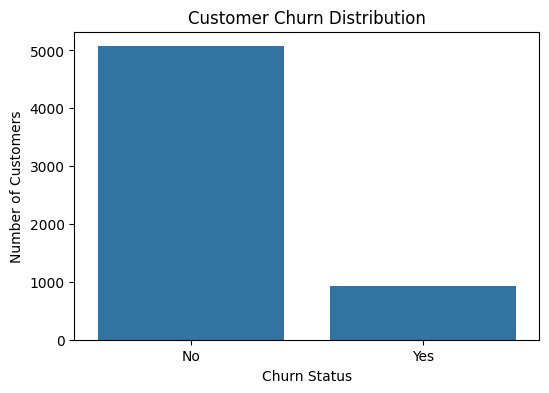

In [ ]:
# Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='churned', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
# Churn Percentage

churn_percentage = df['churned'].value_counts(normalize=True) * 100

print("Churn Percentage:\n")
print(churn_percentage)

Churn Percentage:

churned
No     84.516667
Yes    15.483333
Name: proportion, dtype: float64


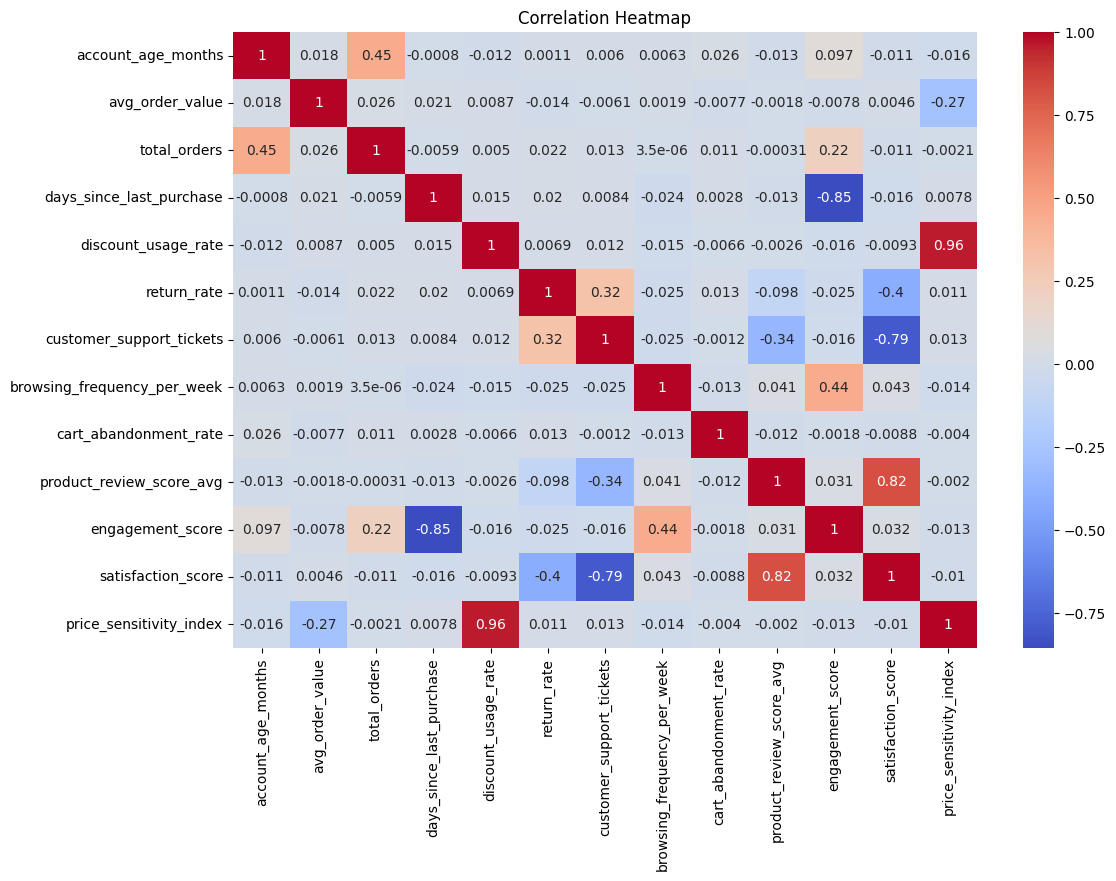

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

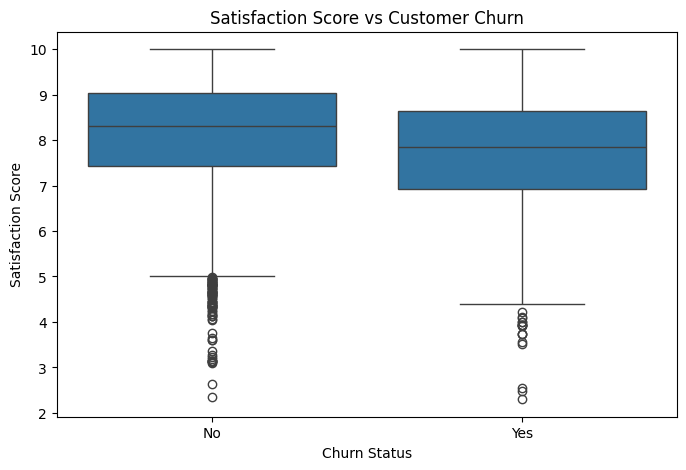

In [ ]:
# Satisfaction Score vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(x='churned', y='satisfaction_score', data=df)

plt.title('Satisfaction Score vs Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Satisfaction Score')

plt.show()

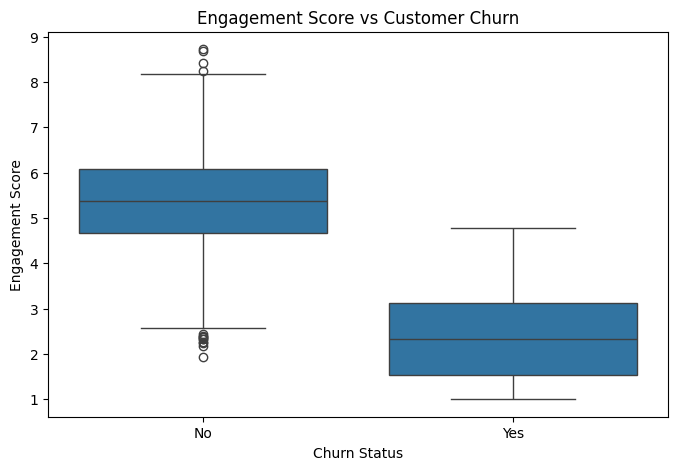

In [ ]:
# Engagement Score vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(x='churned', y='engagement_score', data=df)

plt.title('Engagement Score vs Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Engagement Score')

plt.show()

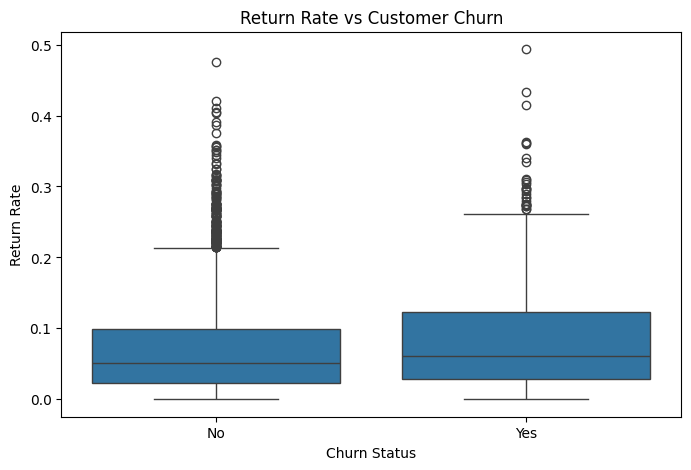

In [ ]:
# Return Rate vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(x='churned', y='return_rate', data=df)

plt.title('Return Rate vs Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Return Rate')

plt.show()

In [ ]:
# Encode Categorical Columns

label_encoder = LabelEncoder()

df['loyalty_member'] = label_encoder.fit_transform(df['loyalty_member'])

df['churned'] = label_encoder.fit_transform(df['churned'])

# Preview Updated Data
display(df.head())

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0


In [ ]:
# Define Features and Target Variable

X = df.drop(['Customer_ID', 'churned'], axis=1)

y = df['churned']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display Shapes

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4800, 14)
Testing Data Shape: (1200, 14)


In [ ]:
# Train Logistic Regression Model

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# Predictions

y_pred_log = log_model.predict(X_test)

# Accuracy Score

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9733333333333334


In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix:\n")
print(cm)

# Classification Report

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_log))

Confusion Matrix:

[[996  11]
 [ 21 172]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1007
           1       0.94      0.89      0.91       193

    accuracy                           0.97      1200
   macro avg       0.96      0.94      0.95      1200
weighted avg       0.97      0.97      0.97      1200



In [ ]:
# Train Random Forest Model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# Predictions

y_pred_rf = rf_model.predict(X_test)

# Accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9666666666666667


In [ ]:
# Confusion Matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:\n")
print(cm_rf)

# Classification Report

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Confusion Matrix:

[[997  10]
 [ 30 163]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1007
           1       0.94      0.84      0.89       193

    accuracy                           0.97      1200
   macro avg       0.96      0.92      0.94      1200
weighted avg       0.97      0.97      0.97      1200



In [ ]:
# Model Comparison

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy]
})

display(comparison)

,Model,Accuracy
0,Logistic Regression,0.973333
1,Random Forest,0.966667


In [ ]:
# Feature Importance using Random Forest

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort Values

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display Top Features

display(feature_importance_df)

,Feature,Importance
11,engagement_score,0.410606
3,days_since_last_purchase,0.368410
12,satisfaction_score,0.039882
10,product_review_score_avg,0.024857
8,browsing_frequency_per_week,0.023499
5,return_rate,0.019913
9,cart_abandonment_rate,0.018659
1,avg_order_value,0.017312
4,discount_usage_rate,0.016123
0,account_age_months,0.014439


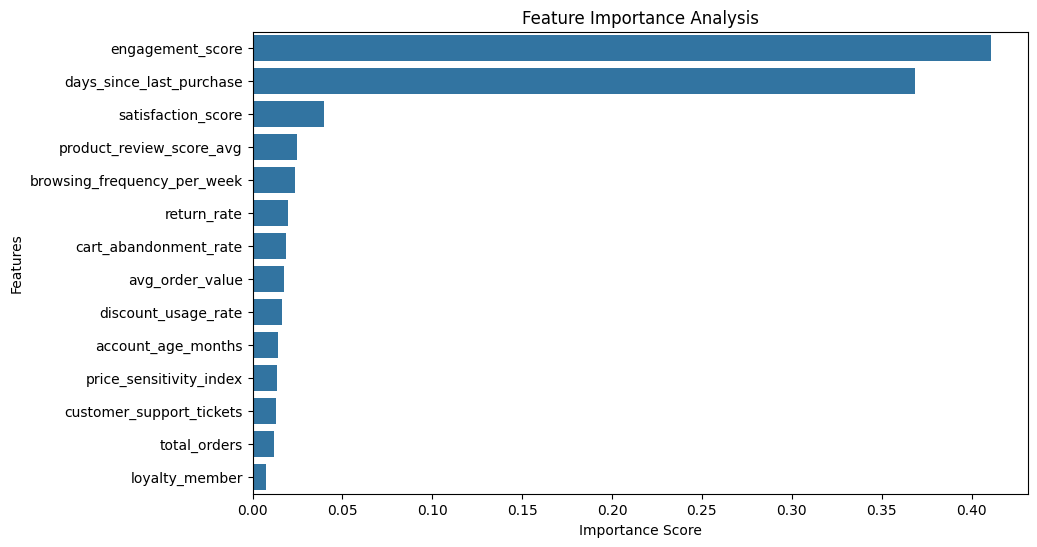

In [ ]:
# Feature Importance Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Feature Importance Analysis')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

In [ ]:
# Churn Distribution Count

print(df['churned'].value_counts())

churned
0    5071
1     929
Name: count, dtype: int64


In [ ]:
# Correlation with Churn

correlation_with_target = df.corr(numeric_only=True)['churned'].sort_values(ascending=False)

print(correlation_with_target)

churned                        1.000000
days_since_last_purchase       0.753358
customer_support_tickets       0.111800
return_rate                    0.079493
discount_usage_rate            0.028757
price_sensitivity_index        0.027008
avg_order_value                0.000666
cart_abandonment_rate         -0.012329
account_age_months            -0.028201
total_orders                  -0.064640
loyalty_member                -0.083788
product_review_score_avg      -0.096535
browsing_frequency_per_week   -0.117835
satisfaction_score            -0.132755
engagement_score              -0.728802
Name: churned, dtype: float64


In [ ]:
joblib.dump(rf_model, 'churn_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully
